In [2]:
dataset_folder = '/mnt/Data1/Nick/transcription_pipeline/'

embryo_datasets = {
    # 22C embryos Var2, 0.230 um/pixel
    '001': [
        'test_data/NSPARC/2025-05-28/MCP-mSG_His-RFP_RBS(001)_embryo01',
        'test_data/NSPARC/2025-05-28/MCP-mSG_His-RFP_RBS(001)_embryo02',
        'test_data/NSPARC/2025-05-28/MCP-mSG_His-RFP_RBS(001)_embryo03',
        'test_data/NSPARC/2025-05-28/MCP-mSG_His-RFP_RBS(001)_embryo04',
    ],

    # 22C embryos PWM, 0.230 um/pixel
    '003': [
        'test_data/NSPARC/2025-05-27/MCP-mSG_His-RFP_RBS(003)_embryo02',
        'test_data/NSPARC/2025-05-29/MCP-mSG_His-RFP_RBS(003)_embryo01',
        'test_data/NSPARC/2025-05-29/MCP-mSG_His-RFP_RBS(003)_embryo02',
    ],

    'test': [
        'test_data/NSPARC/2025-06-16/MCP-mSG_His-RFP_RBS(001)_embryo02',
        'test_data/NSPARC/2025-06-16/MCP-mEGFP_His-RFP_RBS(001)_embryo01',
    ]
}

print(embryo_datasets['001'][0])

test_data/NSPARC/2025-05-28/MCP-mSG_His-RFP_RBS(001)_embryo01


Dataset Path: /mnt/Data1/Nick/transcription_pipeline/test_data/NSPARC/2025-06-16/MCP-mEGFP_His-RFP_RBS(001)_embryo01


/tmp/ipykernel_3158690/3197937074.py:30: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  detected_spots["t_min"] = detected_spots["t_s"] / 60
/tmp/ipykernel_3158690/3197937074.py:31: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  detected_spots["t_bin"] = detected_spots["t_min"].astype(int)


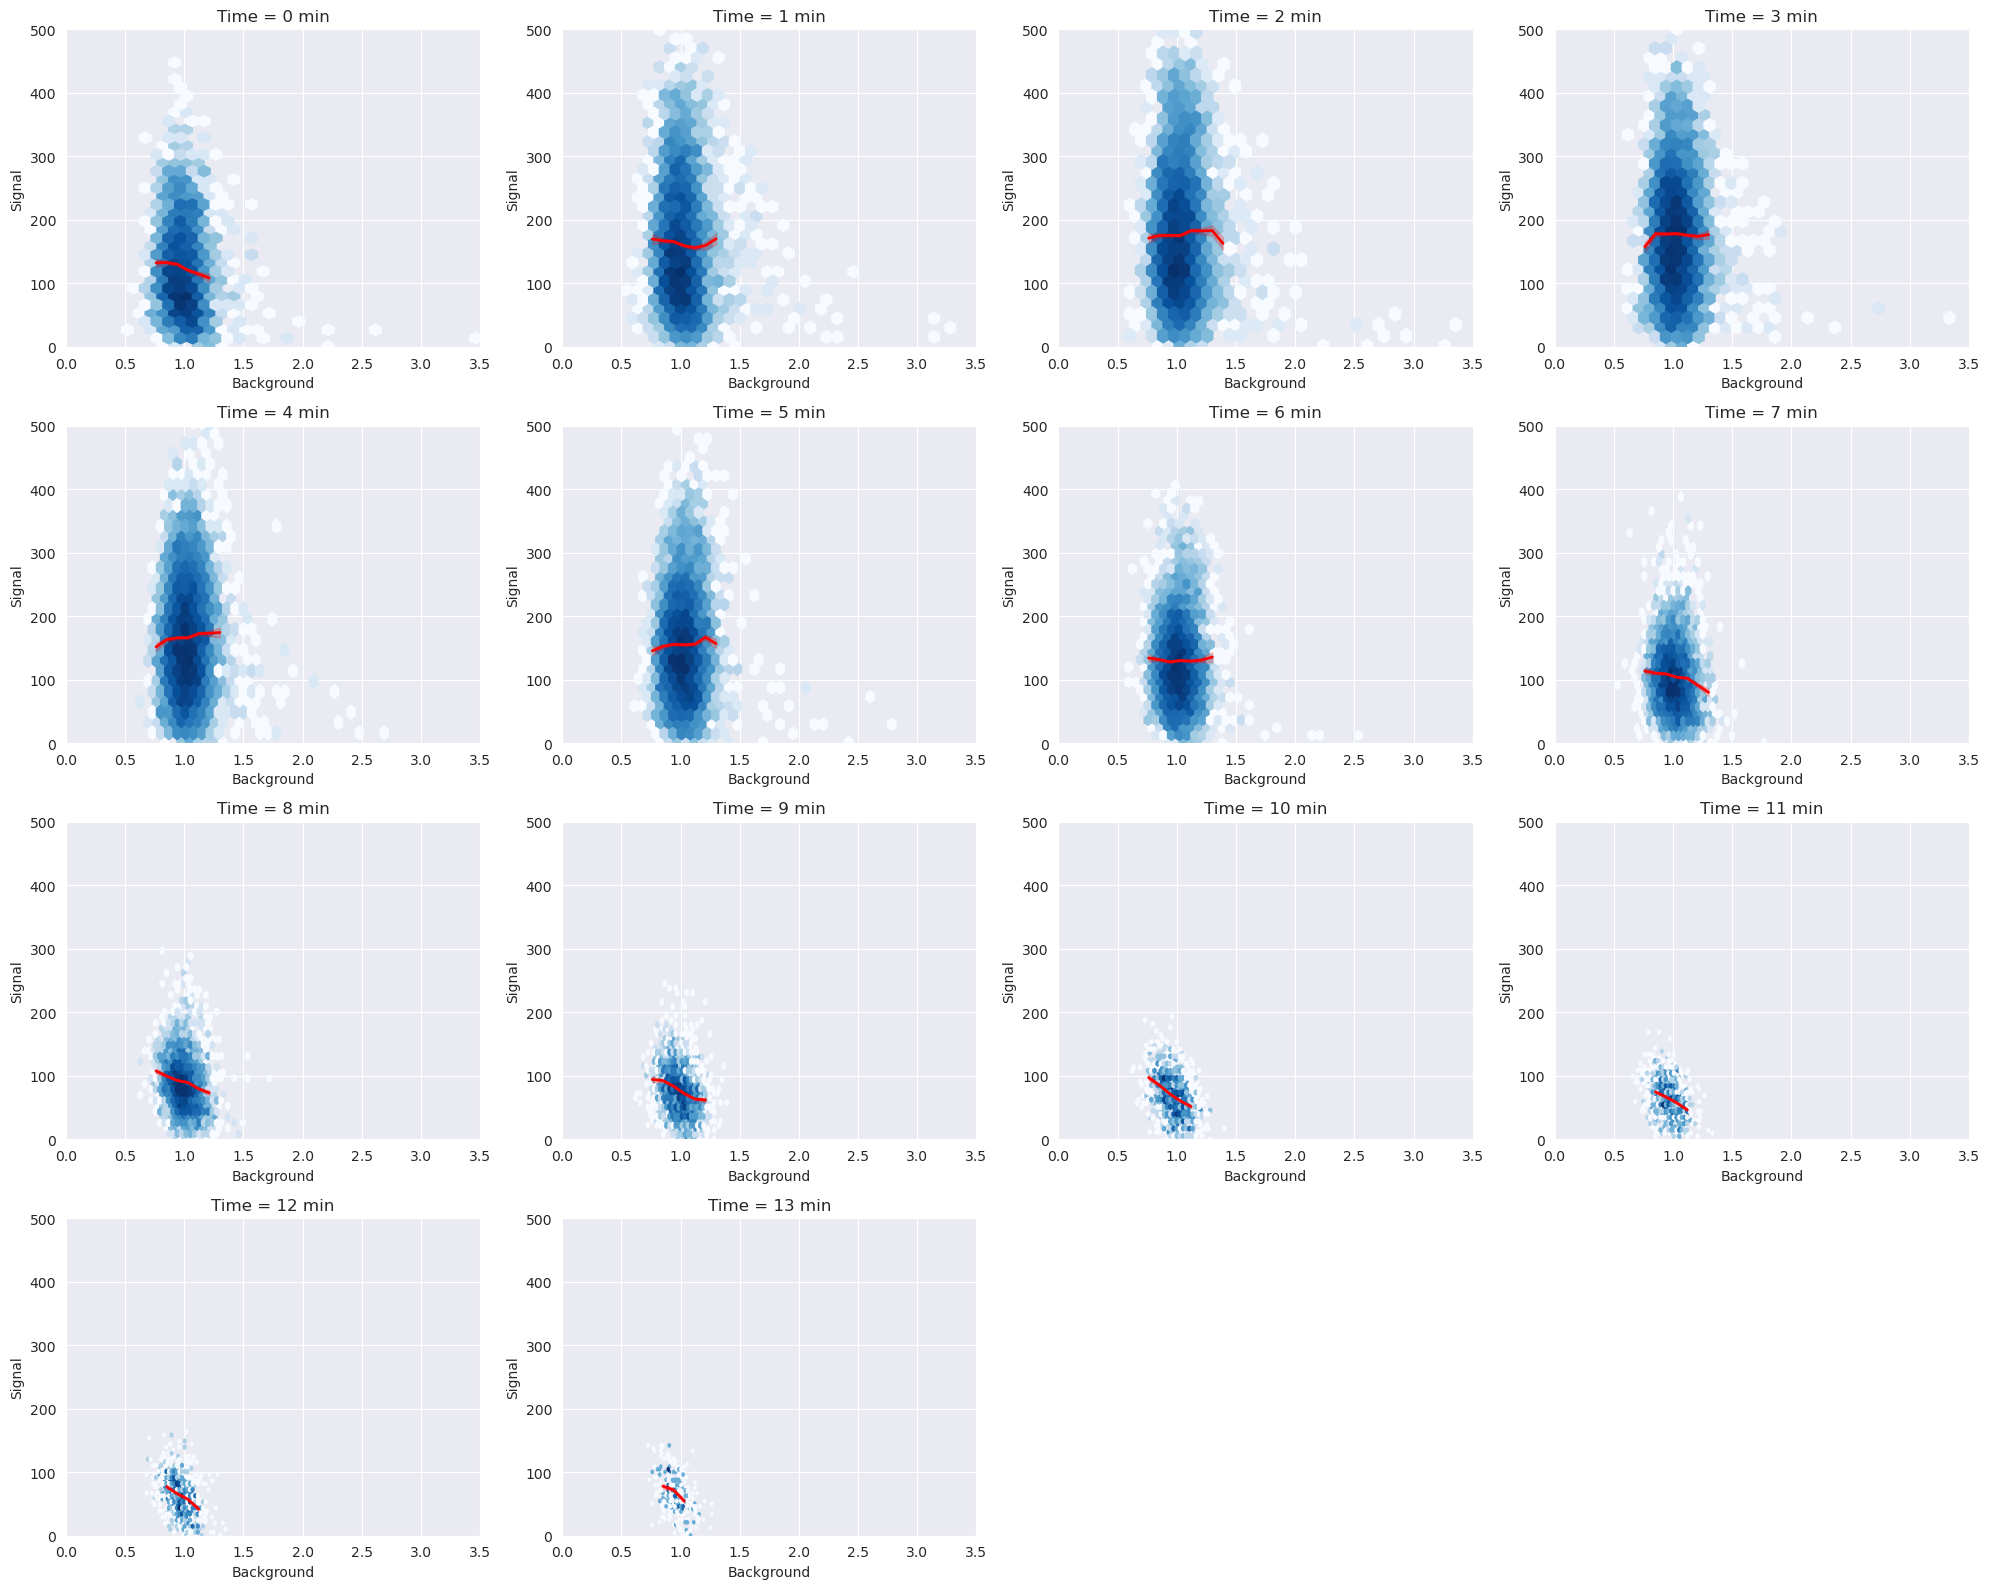

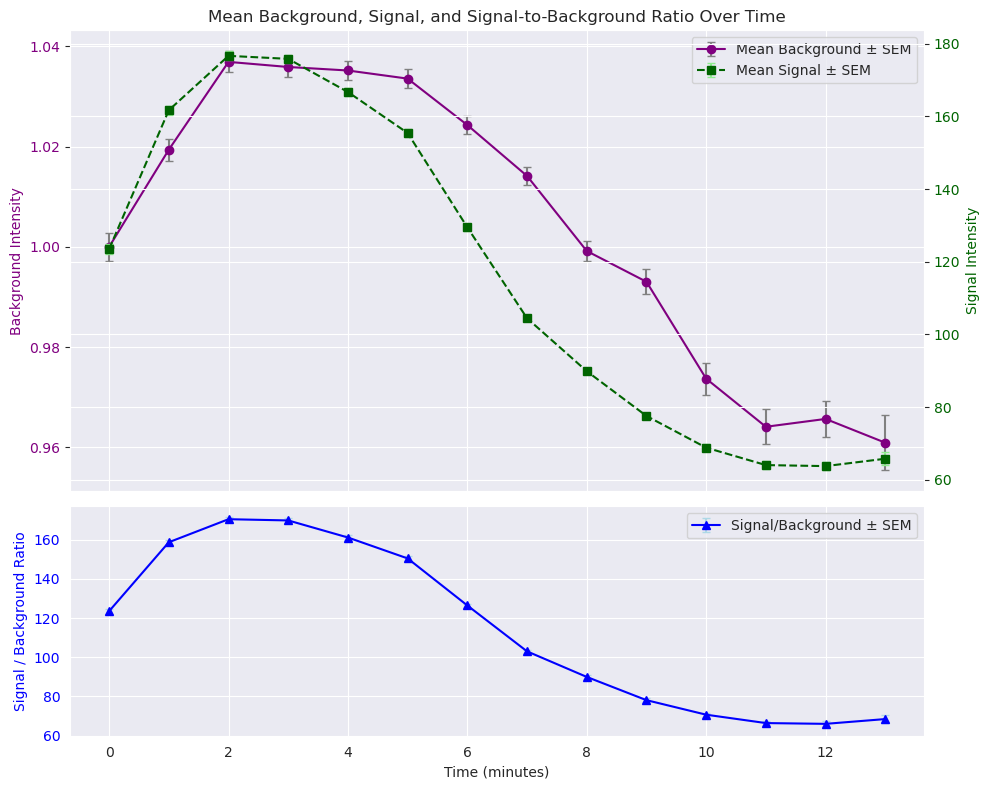

In [5]:
import os
from transcription_pipeline.RateExtraction import FitAndAverage
from transcription_pipeline import spot_pipeline
# from transcription_pipeline import nuclear_pipeline
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from scipy.stats import linregress
import seaborn as sns

# Parameters
nc14_start_frame = 0
min_frames = 40
num_bins = 40

results = []

embryo_id = embryo_datasets['test'][1]
test_dataset_name = os.path.join(dataset_folder, embryo_id)
print('Dataset Path: ' + test_dataset_name)

# --- Load Spot Data ---
spot_tracking = spot_pipeline.Spot()
spot_tracking.read_results(name_folder=test_dataset_name)

spot_df = spot_tracking.spot_dataframe
detected_spots = spot_df[spot_df["particle"] != 0]

# Convert time (t_s) from seconds to minutes
detected_spots["t_min"] = detected_spots["t_s"] / 60
detected_spots["t_bin"] = detected_spots["t_min"].astype(int)

# Group by minute
grouped = detected_spots.groupby("t_bin")

# Plotting
num_plots = len(grouped)
cols = 4
rows = int(np.ceil(num_plots / cols))

fig, axes = plt.subplots(rows, cols, figsize=(5 * cols, 4 * rows))
axes = axes.flatten()

min_points = 50
bins = np.linspace(0, 2.6, 30)  # consistent background range across all plots
bin_centers = (bins[:-1] + bins[1:]) / 2

for i, (minute, group) in enumerate(grouped):
    signal = np.array(group["intensity_from_neighborhood"])
    background = np.array(group["background_intensity_from_neighborhood"])
    digitized = np.digitize(background, bins)

    mean_signal = []
    std_signal = []
    valid_centers = []

    for j in range(1, len(bins)):
        bin_points = signal[digitized == j]
        if len(bin_points) >= min_points:
            mean_signal.append(np.mean(bin_points))
            std_signal.append(np.std(bin_points) / np.sqrt(len(bin_points)))
            valid_centers.append(bin_centers[j - 1])

    ax = axes[i]
    hb = ax.hexbin(background, signal, gridsize=30, cmap='Blues', bins='log')
    ax.plot(valid_centers, mean_signal, 'r-', linewidth=2)
    ax.fill_between(valid_centers,
                    np.array(mean_signal) - np.array(std_signal),
                    np.array(mean_signal) + np.array(std_signal),
                    color='red', alpha=0.2)
    ax.set_xlim(0, 3.5)
    ax.set_ylim(0,500)
    ax.set_title(f'Time = {minute} min')
    ax.set_xlabel('Background')
    ax.set_ylabel('Signal')

# Hide any extra subplots
for j in range(i + 1, len(axes)):
    axes[j].axis('off')

plt.tight_layout()
plt.show()

# --- Compute stats for signal and background over time ---
avg_background = grouped["background_intensity_from_neighborhood"].mean()
std_background = grouped["background_intensity_from_neighborhood"].std()

avg_signal = grouped["intensity_from_neighborhood"].mean()
std_signal = grouped["intensity_from_neighborhood"].std()

count_per_bin = grouped.size()
sem_background = std_background / np.sqrt(count_per_bin)
sem_signal = std_signal / np.sqrt(count_per_bin)

# --- Compute signal-to-background ratio and its SEM ---
ratio = avg_signal / avg_background
sem_ratio = ratio * np.sqrt((sem_signal / avg_signal)**2 + (sem_background / avg_background)**2)

# --- Plot background and signal with shared gridlines ---
fig, (ax_top, ax_bot) = plt.subplots(2, 1, figsize=(10, 8), sharex=True, height_ratios=[2, 1])

# --- Top plot: Background and Signal ---
# Background (primary axis)
ax1 = ax_top
ax2 = ax1.twinx()

ax1.errorbar(avg_background.index, avg_background, yerr=sem_background,
             fmt='o-', color='purple', ecolor='gray', capsize=3, label='Mean Background ± SEM')
ax1.set_ylabel('Background Intensity', color='purple')
ax1.tick_params(axis='y', labelcolor='purple')
ax1.grid(True)

# Signal (secondary axis)
ax2.errorbar(avg_signal.index, avg_signal, yerr=sem_signal,
             fmt='s--', color='darkgreen', ecolor='lightgreen', capsize=3, label='Mean Signal ± SEM')
ax2.set_ylabel('Signal Intensity', color='darkgreen')
ax2.tick_params(axis='y', labelcolor='darkgreen')
ax2.set_facecolor('none')

# Combine legends
lines1, labels1 = ax1.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax1.legend(lines1 + lines2, labels1 + labels2, loc='upper right')

# Title
ax1.set_title('Mean Background, Signal, and Signal-to-Background Ratio Over Time')

# --- Bottom plot: Ratio ---
ax_bot.errorbar(ratio.index, ratio, yerr=sem_ratio,
                fmt='^-', color='blue', ecolor='lightblue', capsize=3, label='Signal/Background ± SEM')
ax_bot.set_xlabel('Time (minutes)')
ax_bot.set_ylabel('Signal / Background Ratio', color='blue')
ax_bot.tick_params(axis='y', labelcolor='blue')
ax_bot.grid(True)
ax_bot.legend(loc='upper right')

# Final layout
fig.tight_layout()
plt.show()





In [3]:
detected_spots

,label,z,y,x,frame,t_s,t_frame,raw_spot,coordinates_start,covariance_matrix,...,norm_cost,intensity_from_fit,intensity_std_error_from_fit,intensity_from_neighborhood,intensity_std_error_from_neighborhood,background_intensity_from_neighborhood,background_intensity_std_error_from_neighborhood,particle,t_min,t_bin
1,37,2.914354,58.765742,427.315842,0,2.767961,1,"[[[1, 0, 0, 0, 0, 0, 0, 0, 0], [3, 1, 1, 0, 1,...","[0, 0, 54, 422]","[[0.03155824831414064, 2.4055666034096463e-06,...",...,0.012092,43.887361,8.946474,52.143262,19.488762,0.774713,0.072222,4200,0.046133,0
2,84,5.714223,35.142089,532.118526,0,3.289956,1,"[[[1, 0, 1, 1, 1, 1, 1, 0, 0], [0, 0, 1, 0, 1,...","[0, 3, 30, 527]","[[0.025718927046593665, 2.0032828268037658e-07...",...,0.015194,53.064451,11.613548,2.321069,20.455306,0.858517,0.077332,3467,0.054833,0
3,97,6.608517,164.657843,159.494559,0,3.463997,1,"[[[1, 2, 2, 1, 2, 0, 1, 2, 0], [1, 0, 1, 2, 1,...","[0, 4, 160, 155]","[[0.049359035251661625, 3.152304380475941e-08,...",...,0.014298,89.940436,17.428117,62.355194,19.691338,1.087504,0.067636,3642,0.057733,0
4,110,7.345563,94.677563,178.606535,0,3.463997,1,"[[[0, 3, 1, 3, 1, 0, 1, 2, 1], [0, 1, 1, 1, 0,...","[0, 4, 90, 174]","[[0.1394305114277351, 4.5447887529567763e-07, ...",...,0.019864,126.509547,36.171956,78.652429,20.332780,1.033786,0.077665,2837,0.057733,0
7,141,9.807967,53.871107,355.144135,0,3.985993,1,"[[[0, 1, 0, 0, 0, 2, 1, 1, 1], [2, 1, 1, 0, 0,...","[0, 7, 49, 350]","[[0.030678930547909152, 5.5776832420909706e-08...",...,0.009682,197.615452,26.991680,186.022073,22.040827,0.844171,0.069507,3955,0.066433,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
74736,766,13.732854,224.357748,307.284130,398,810.032993,400,"[[[1, 0, 0, 2, 1, 3, 2, 2, 1], [0, 2, 1, 2, 3,...","[14, 11, 219, 302]","[[0.01598751064280991, -2.0612869721978e-06, -...",...,0.009407,37.808527,7.064652,50.492725,23.218793,0.951451,0.080306,23,13.500550,13
74738,818,15.930223,51.242775,477.090955,398,810.380960,400,"[[[3, 3, 2, 0, 1, 2, 1, 3, 0], [1, 1, 1, 1, 0,...","[14, 13, 46, 472]","[[0.014099649480203655, -4.599442897474351e-05...",...,0.007585,20.068066,5.101703,5.049396,23.095731,1.049658,0.089263,25,13.506349,13
74739,821,16.621663,63.314718,368.876989,398,810.554880,400,"[[[0, 2, 0, 0, 0, 0, 0, 0, 0], [3, 2, 0, 0, 0,...","[14, 14, 59, 364]","[[0.039769832410906425, -6.862638398043209e-07...",...,0.017247,142.032451,31.145724,100.558124,23.000771,0.875147,0.074887,26,13.509248,13
74740,843,16.132771,169.950306,337.389881,398,810.380960,400,"[[[1, 1, 2, 4, 1, 1, 1, 1, 1], [2, 1, 1, 4, 1,...","[14, 13, 165, 332]","[[0.02481434358013609, 2.0539049001040764e-07,...",...,0.012608,52.081818,10.404934,79.309818,20.262063,0.801727,0.073961,27,13.506349,13


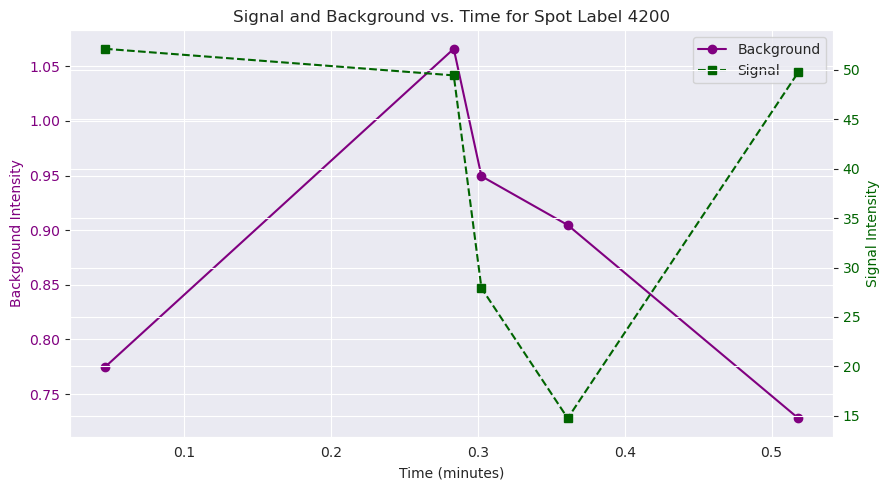

In [6]:
def plot_spot_trace(label_id):
    spot_trace = detected_spots[detected_spots["particle"] == label_id].sort_values("t_min")
    time = spot_trace["t_min"]
    signal = spot_trace["intensity_from_neighborhood"]
    background = spot_trace["background_intensity_from_neighborhood"]

    fig, ax1 = plt.subplots(figsize=(9, 5))
    ax1.plot(time, background, 'o-', color='purple', label='Background')
    ax1.set_xlabel("Time (minutes)")
    ax1.set_ylabel("Background Intensity", color='purple')
    ax1.tick_params(axis='y', labelcolor='purple')
    ax1.grid(True)

    ax2 = ax1.twinx()
    ax2.plot(time, signal, 's--', color='darkgreen', label='Signal')
    ax2.set_ylabel("Signal Intensity", color='darkgreen')
    ax2.tick_params(axis='y', labelcolor='darkgreen')
    ax2.set_facecolor('none')

    lines1, labels1 = ax1.get_legend_handles_labels()
    lines2, labels2 = ax2.get_legend_handles_labels()
    ax1.legend(lines1 + lines2, labels1 + labels2, loc='upper right')

    plt.title(f"Signal and Background vs. Time for Spot Label {label_id}")
    fig.tight_layout()
    plt.show()
    plt.close()

# Example usage
plot_spot_trace(4200)
